In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv(
    "../data/raw/telco.csv"
)

df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


In [7]:
df.shape

(7043, 22)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null   str    
 4   Partner           7043 non-null   str    
 5   Dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   str    
 8   MultipleLines     7043 non-null   str    
 9   InternetService   7043 non-null   str    
 10  OnlineSecurity    7043 non-null   str    
 11  OnlineBackup      7043 non-null   str    
 12  DeviceProtection  7043 non-null   str    
 13  TechSupport       7043 non-null   str    
 14  StreamingTV       7043 non-null   str    
 15  StreamingMovies   7043 non-null   str    
 16  Contract          7043 non-null   str    
 17  Paperl

In [9]:
df.isnull().sum()

Unnamed: 0          0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["Churn"].value_counts()

Churn
Stayed     5174
Churned    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True)

Churn
Stayed     0.73463
Churned    0.26537
Name: proportion, dtype: float64

In [12]:
df.describe()

,Unnamed: 0,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,3521.000000,32.371149,64.761692
std,2033.283305,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,1760.500000,9.000000,35.500000
50%,3521.000000,29.000000,70.350000
75%,5281.500000,55.000000,89.850000
max,7042.000000,72.000000,118.750000


In [13]:
df.describe(include="object")

/var/folders/qb/gkvqj6ks2336l83mcykvf0mr0000gn/T/ipykernel_52555/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,4,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,Stayed
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


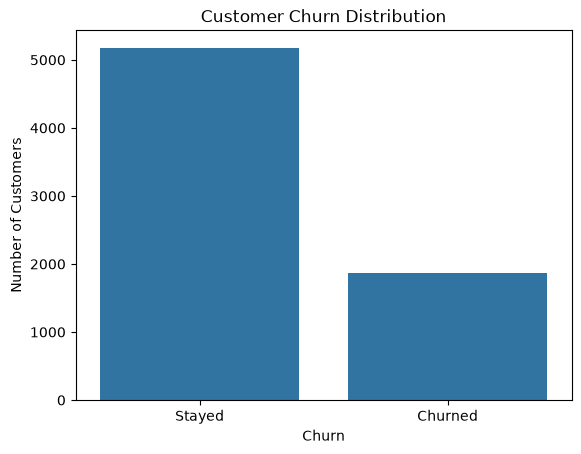

In [14]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [162]:
X = df.drop(
    columns=["Churn", "customerID", "Unnamed: 0"]
)
y = df["Churn"]

In [163]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [164]:
y.value_counts()

Churn
Stayed     5174
Churned    1869
Name: count, dtype: int64

In [165]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/qb/gkvqj6ks2336l83mcykvf0mr0000gn/T/ipykernel_52555/1835835371.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [166]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.preprocessing import create_preprocessor

In [167]:
preprocessor = create_preprocessor(
    numeric_features,
    categorical_features
)

In [168]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [169]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [170]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)
print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Training shape: (5634, 47)
Testing shape: (1409, 47)
Original features: 19
Processed features: 47


In [171]:
from src.models import create_models

In [172]:
models = create_models(
    numeric_features,
    categorical_features
)

In [173]:
models.keys()

dict_keys(['logistic_regression', 'random_forest', 'svm'])

In [174]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(
        X_train,
        y_train
    )
    
    print(f"{name} trained successfully.")

Training logistic_regression...
logistic_regression trained successfully.
Training random_forest...
random_forest trained successfully.
Training svm...


/Users/syedarhan/study/Gen ai/projects/churn-prediction-api/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm trained successfully.


In [175]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

In [176]:
for name, model in models.items():
    print(name, model.classes_)

logistic_regression ['Churned' 'Stayed']
random_forest ['Churned' 'Stayed']
svm ['Churned' 'Stayed']


In [177]:
probabilities = {}

for name, model in models.items():
    probabilities[name] = model.predict_proba(X_test)[:, 0]

In [178]:
probabilities["logistic_regression"]

array([0.03069018, 0.33766067, 0.17276663, ..., 0.85422924, 0.39650393,
       0.08938815], shape=(1409,))

In [179]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

In [180]:
y_test_binary = (
    y_test == "Churned"
).astype(int)

In [181]:
results = []

for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label="Churned"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label="Churned"
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            pos_label="Churned"
        ),
        "ROC-AUC": roc_auc_score(
            y_test_binary,
            y_prob
        ),
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,logistic_regression,0.750177,0.519231,0.794118,0.627907,0.831818
2,svm,0.744500,0.512238,0.783422,0.619450,0.826910
1,random_forest,0.759404,0.539503,0.639037,0.585067,0.814847


In [182]:
probabilities[name] = model.predict_proba(X_test)[:, 0]

In [183]:
for name in models:
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions[name]
        )
    )

logistic_regression
              precision    recall  f1-score   support

     Churned       0.52      0.79      0.63       374
      Stayed       0.91      0.73      0.81      1035

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

random_forest
              precision    recall  f1-score   support

     Churned       0.54      0.64      0.59       374
      Stayed       0.86      0.80      0.83      1035

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

svm
              precision    recall  f1-score   support

     Churned       0.51      0.78      0.62       374
      Stayed       0.90      0.73      0.81      1035

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74   

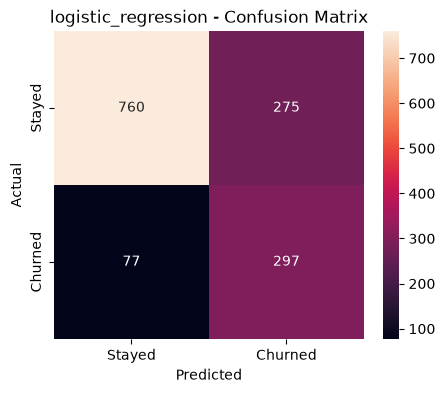

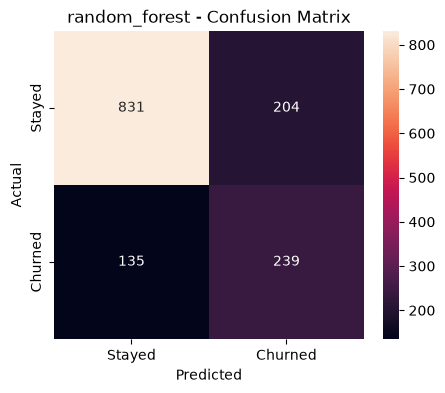

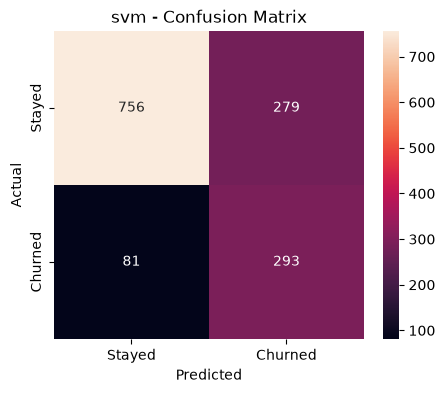

In [184]:
for name in models:
    cm = confusion_matrix(
        y_test,
        predictions[name],
        labels=["Stayed", "Churned"]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [185]:
results_df.to_csv(
    "../data/model_comparison.csv",
    index=False
)

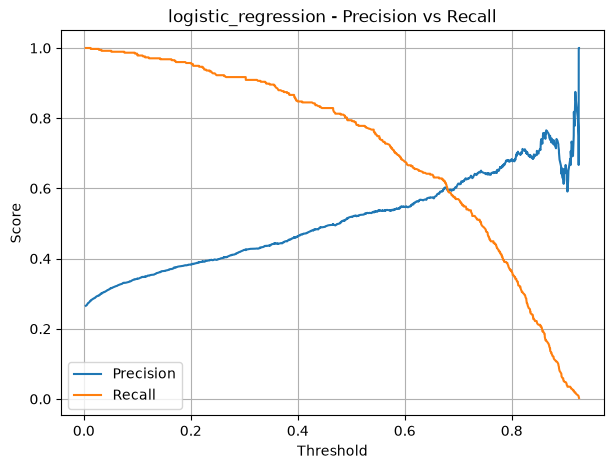

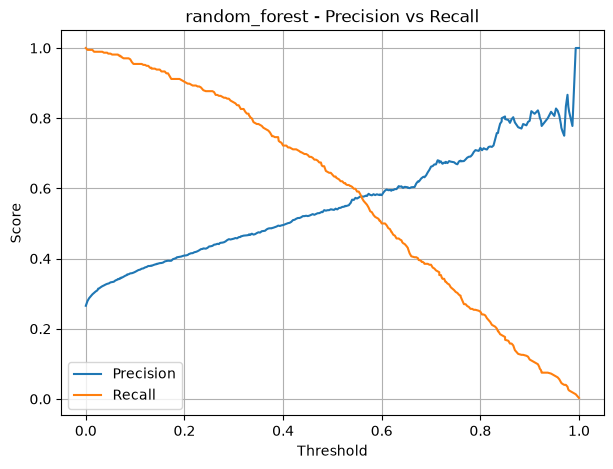

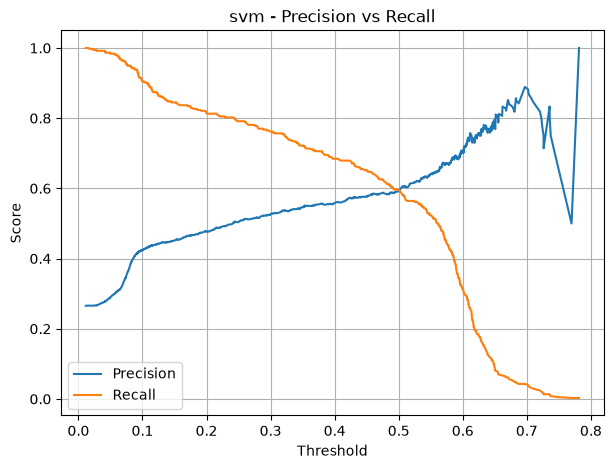

In [186]:
from sklearn.metrics import precision_recall_curve

for name in models:
    y_prob = probabilities[name]

    precision, recall, thresholds = precision_recall_curve(
        y_test_binary,
        y_prob
    )

    plt.figure(figsize=(7, 5))

    plt.plot(
        thresholds,
        precision[:-1],
        label="Precision"
    )

    plt.plot(
        thresholds,
        recall[:-1],
        label="Recall"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{name} - Precision vs Recall")
    plt.legend()
    plt.grid()
    plt.show()

In [187]:
threshold_results = {}

for name in models:
    y_prob = probabilities[name]

    precision, recall, thresholds = precision_recall_curve(
        y_test_binary,
        y_prob
    )

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    best_index = np.argmax(f1_scores)

    threshold_results[name] = {
        "threshold": thresholds[best_index],
        "precision": precision[best_index],
        "recall": recall[best_index],
        "f1": f1_scores[best_index],
    }

threshold_results

{'logistic_regression': {'threshold': np.float64(0.5419728393969605),
  'precision': np.float64(0.533457249070632),
  'recall': np.float64(0.767379679144385),
  'f1': np.float64(0.6293859600739652)},
 'random_forest': {'threshold': np.float64(0.44),
  'precision': np.float64(0.5208747514910537),
  'recall': np.float64(0.7005347593582888),
  'f1': np.float64(0.5974914432267671)},
 'svm': {'threshold': np.float64(0.3188276192021528),
  'precision': np.float64(0.5370018975332068),
  'recall': np.float64(0.7566844919786097),
  'f1': np.float64(0.6281908941452894)}}

In [188]:
threshold_df = pd.DataFrame(
    threshold_results
).T

threshold_df

,threshold,precision,recall,f1
logistic_regression,0.541973,0.533457,0.767380,0.629386
random_forest,0.440000,0.520875,0.700535,0.597491
svm,0.318828,0.537002,0.756684,0.628191


In [189]:
final_model_name = "logistic_regression"

final_model = models[final_model_name]

final_threshold = threshold_results[
    final_model_name
]["threshold"]

print("Final model:", final_model_name)
print("Final threshold:", final_threshold)

Final model: logistic_regression
Final threshold: 0.5419728393969605


In [190]:
final_probabilities = probabilities[final_model_name]

final_predictions = np.where(
    final_probabilities >= final_threshold,
    "Churned",
    "Stayed"
)

In [191]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

     Churned       0.53      0.77      0.63       374
      Stayed       0.90      0.76      0.82      1035

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [192]:
print(
    "Confusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        final_predictions,
        labels=["Stayed", "Churned"]
    )
)

Confusion Matrix:
[[784 251]
 [ 87 287]]


In [193]:
final_model_name = "logistic_regression"
final_threshold = threshold_results["logistic_regression"]["threshold"]

print("Final model:", final_model_name)
print("Final threshold:", final_threshold)

Final model: logistic_regression
Final threshold: 0.5419728393969605


In [194]:
final_config = {
    "model": final_model_name,
    "threshold": final_threshold,
    "positive_class": "Churned"
}

final_config

{'model': 'logistic_regression',
 'threshold': np.float64(0.5419728393969605),
 'positive_class': 'Churned'}

In [195]:
import joblib

joblib.dump(
    final_model,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [196]:
joblib.dump(
    {
        "threshold": final_threshold,
        "positive_class": "Churned"
    },
    "../models/churn_config.joblib"
)

['../models/churn_config.joblib']

In [197]:
loaded_model = joblib.load(
    "../models/churn_model.joblib"
)

loaded_config = joblib.load(
    "../models/churn_config.joblib"
)

print(loaded_model)
print(loaded_config)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(ha

In [198]:
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 0]

loaded_predictions = np.where(
    loaded_probabilities >= loaded_config["threshold"],
    "Churned",
    "Stayed"
)

print(
    classification_report(
        y_test,
        loaded_predictions
    )
)

              precision    recall  f1-score   support

     Churned       0.53      0.77      0.63       374
      Stayed       0.90      0.76      0.82      1035

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [199]:
print(X.columns.tolist())
print(X.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
(7043, 19)


In [200]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [201]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/qb/gkvqj6ks2336l83mcykvf0mr0000gn/T/ipykernel_52555/2612815418.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [202]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [203]:
from src.models import create_models

models = create_models(
    numeric_features,
    categorical_features
)

In [204]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Training logistic_regression...
logistic_regression trained successfully.
Training random_forest...
random_forest trained successfully.
Training svm...


/Users/syedarhan/study/Gen ai/projects/churn-prediction-api/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm trained successfully.
